In [82]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests

# Fetch the data.
df = pd.read_csv("https://ourworldindata.org/grapher/children-born-per-woman.csv?v=1&csvType=full&useColumnShortNames=true", storage_options = {'User-Agent': 'Our World In Data data fetch/1.0'})

# Fetch the metadata
metadata = requests.get("https://ourworldindata.org/grapher/children-born-per-woman.metadata.json?v=1&csvType=full&useColumnShortNames=true").json()

In [83]:
df.head(3)

,entity,code,year,fertility_rate_hist
0,Afghanistan,AFG,1950,7.248
1,Afghanistan,AFG,1951,7.260
2,Afghanistan,AFG,1952,7.260


In [84]:
df.shape

(19402, 4)

In [85]:
japon = df[df["entity"] == "Japan"]

In [86]:
mexico = df[df["entity"] == "Mexico"]

In [87]:
type(mexico)

pandas.DataFrame

In [88]:
japon.head()

,entity,code,year,fertility_rate_hist
8384,Japan,JPN,1947,4.614
8385,Japan,JPN,1948,4.463
8386,Japan,JPN,1949,4.373
8387,Japan,JPN,1950,3.615
8388,Japan,JPN,1951,3.225


In [89]:
japon.head(10)

,entity,code,year,fertility_rate_hist
8384,Japan,JPN,1947,4.614
8385,Japan,JPN,1948,4.463
8386,Japan,JPN,1949,4.373
8387,Japan,JPN,1950,3.615
8388,Japan,JPN,1951,3.225
8389,Japan,JPN,1952,2.947
8390,Japan,JPN,1953,2.673
8391,Japan,JPN,1954,2.468
8392,Japan,JPN,1955,2.349
8393,Japan,JPN,1956,2.206


In [90]:
type(df["entity"])

pandas.Series

In [91]:
anios_mexico = mexico["year"].to_numpy()
tasa_mexico = mexico["fertility_rate_hist"].to_numpy()

anios_japon = japon["year"].to_numpy()
tasa_japon = japon["fertility_rate_hist"].to_numpy()

In [92]:
type(anios_mexico)

numpy.ndarray

In [93]:
type(tasa_mexico)

numpy.ndarray

In [94]:
type(anios_japon)

numpy.ndarray

In [95]:
type(tasa_japon)

numpy.ndarray

In [96]:
promedio_mexico = np.mean(tasa_mexico)
maximo_mexico = np.max(tasa_mexico)
minimo_mexico = np.min(tasa_mexico)
desviacion_mexico = np.std(tasa_mexico)

In [97]:
print("Promedio:", promedio_mexico)
print("Máximo:", maximo_mexico)
print("Mínimo:", minimo_mexico)
print("Desviación estándar:", desviacion_mexico)

Promedio: 4.326364864864865
Máximo: 6.833
Mínimo: 1.91
Desviación estándar: 1.8802504834162772


In [98]:
promedio_japon = np.mean(tasa_japon)
maximo_japon = np.max(tasa_japon)
minimo_japon = np.min(tasa_japon)
desviacion_japon = np.std(tasa_japon)

In [99]:
print("Promedio:", promedio_japon)
print("Máximo:", maximo_japon)
print("Mínimo:", minimo_japon)
print("Desviación estándar:", desviacion_japon)

Promedio: 1.8388051948051947
Máximo: 4.614
Mínimo: 1.208
Desviación estándar: 0.7018619770141482


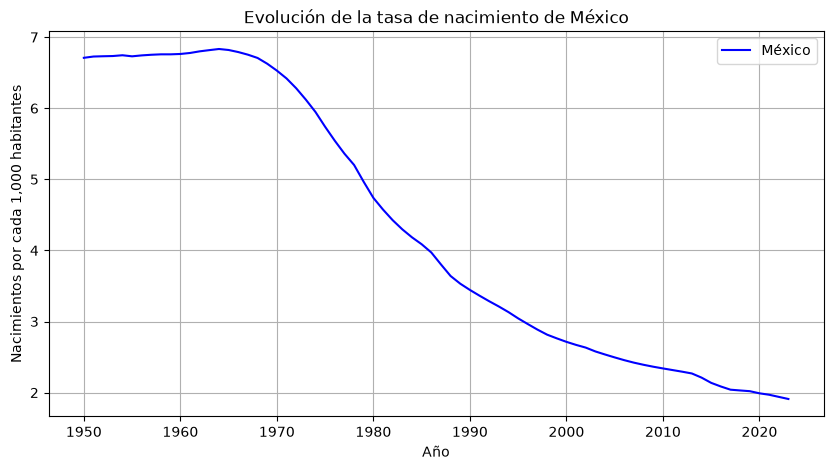

In [100]:
plt.figure(figsize=(10, 5))
plt.plot(
anios_mexico, 
tasa_mexico, 
label="México", 
color="blue"
)

plt.title("Evolución de la tasa de nacimiento de México")
plt.xlabel("Año")
plt.ylabel("Nacimientos por cada 1,000 habitantes")
plt.grid(True)
plt.legend()

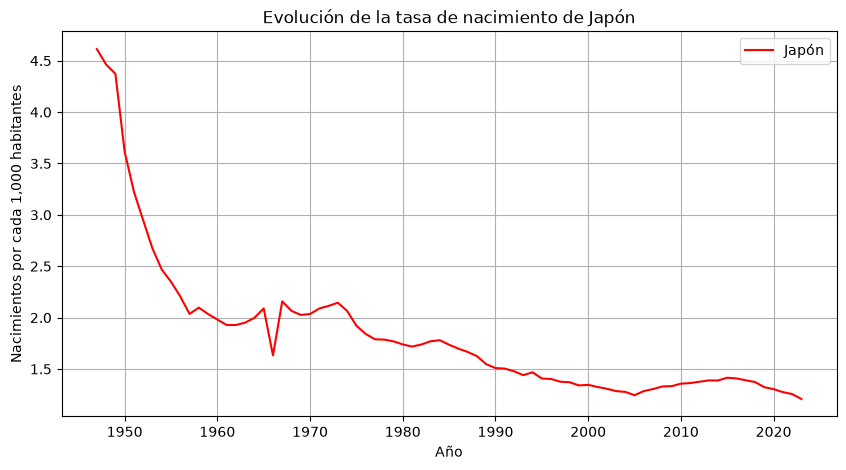

In [101]:
plt.figure(figsize=(10, 5))
plt.plot(
anios_japon, 
tasa_japon, 
label="Japón", 
color="red"
)

plt.title("Evolución de la tasa de nacimiento de Japón")
plt.xlabel("Año")
plt.ylabel("Nacimientos por cada 1,000 habitantes")
plt.grid(True)
plt.legend()

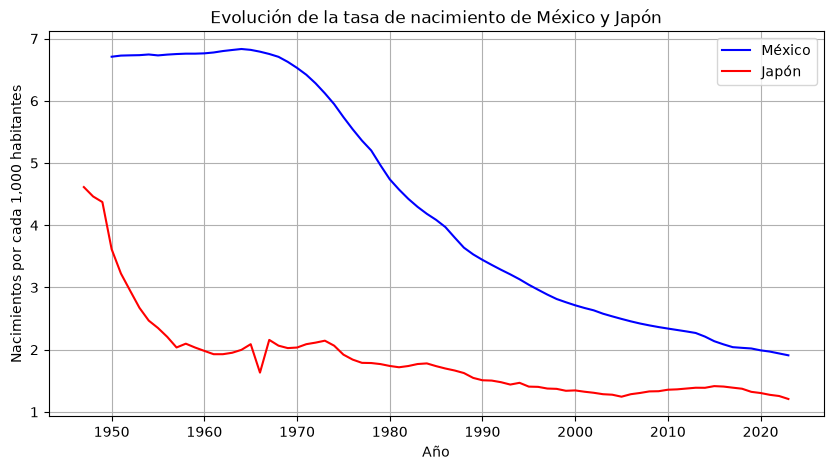

In [102]:
plt.figure(figsize=(10, 5))
plt.plot(
anios_mexico, 
tasa_mexico, 
label="México", 
color="blue"
)
plt.plot(
anios_japon, 
tasa_japon, 
label="Japón", 
color="red"
)

plt.title("Evolución de la tasa de nacimiento de México y Japón")
plt.xlabel("Año")
plt.ylabel("Nacimientos por cada 1,000 habitantes")
plt.grid(True)
plt.legend()

In [103]:
japon.shape

(77, 4)

In [104]:
mexico.shape

(74, 4)

In [105]:
##Error porque no son de la misma longitud, por lo que no se pueden restar directamente.
diferencia = tasa_mexico - tasa_japon

ValueError: operands could not be broadcast together with shapes (74,) (77,) 

In [ ]:
mascara_coincidencia_anios = anios_japon >= anios_mexico.min()

In [ ]:
mascara_coincidencia_anios

array([False, False, False,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True])

In [ ]:
tasa_japon = tasa_japon[mascara_coincidencia_anios]

In [ ]:
tasa_japon.shape

(74,)

In [ ]:
diferencia = tasa_mexico - tasa_japon

In [ ]:
diferencia

array([3.094, 3.502, 3.784, 4.061, 4.277, 4.381, 4.537, 4.716, 4.661,
       4.723, 4.782, 4.849, 4.872, 4.866, 4.835, 4.73 , 5.158, 4.595,
       4.642, 4.6  , 4.494, 4.33 , 4.167, 3.976, 3.882, 3.818, 3.702,
       3.572, 3.416, 3.195, 3.   , 2.856, 2.687, 2.526, 2.404, 2.351,
       2.273, 2.137, 2.015, 1.985, 1.935, 1.859, 1.807, 1.771, 1.664,
       1.637, 1.561, 1.51 , 1.444, 1.423, 1.368, 1.346, 1.325, 1.294,
       1.259, 1.25 , 1.171, 1.116, 1.061, 1.031, 0.983, 0.954, 0.918,
       0.88 , 0.823, 0.722, 0.678, 0.651, 0.657, 0.697, 0.686, 0.695,
       0.684, 0.702])

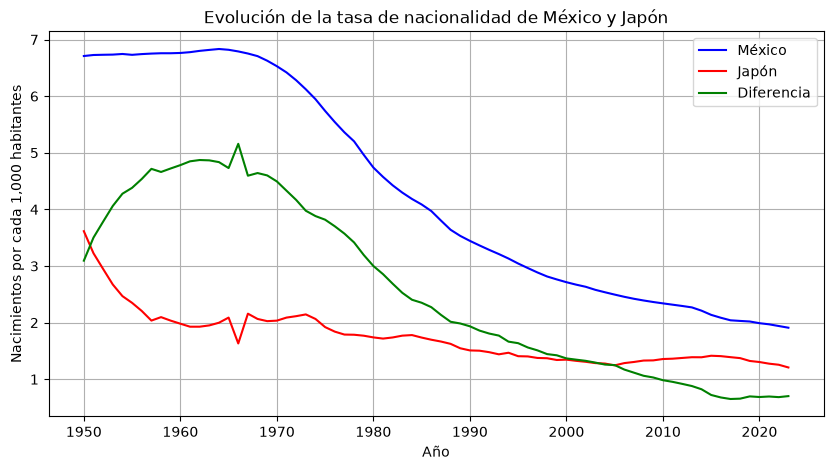

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(
anios_mexico, 
tasa_mexico, 
label="México", 
color="blue"
)
plt.plot(
anios_japon, 
tasa_japon, 
label="Japón", 
color="red"
)
plt.plot(
anios_mexico,
diferencia,
label="Diferencia",
color="green"
)

plt.title("Evolución de la tasa de natalidad")
plt.xlabel("Año")
plt.ylabel("Nacimientos por cada 1,000 habitantes")
plt.grid(True)
plt.legend()


In [ ]:
brasil = df[df["entity"] == "Brazil"]

In [ ]:
anios_brasil = brasil["year"].to_numpy()
tasa_brasil = brasil["fertility_rate_hist"].to_numpy()

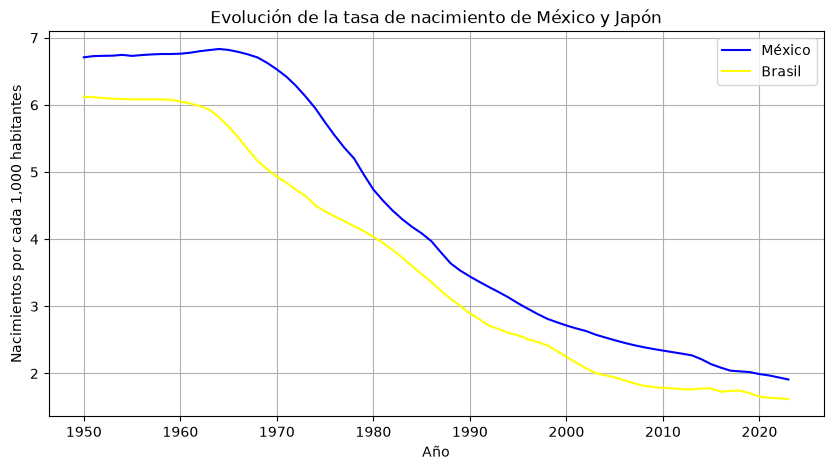

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(
anios_mexico, 
tasa_mexico, 
label="México", 
color="blue"
)
plt.plot(
anios_brasil, 
tasa_brasil,
label="Brasil",
color="yellow"
)

plt.title("Evolución de la tasa de nacimiento de México y Brasil")
plt.xlabel("Año")
plt.ylabel("Nacimientos por cada 1,000 habitantes")
plt.grid(True)
plt.legend()

In [108]:
deiferencia_brasil = tasa_mexico - tasa_brasil

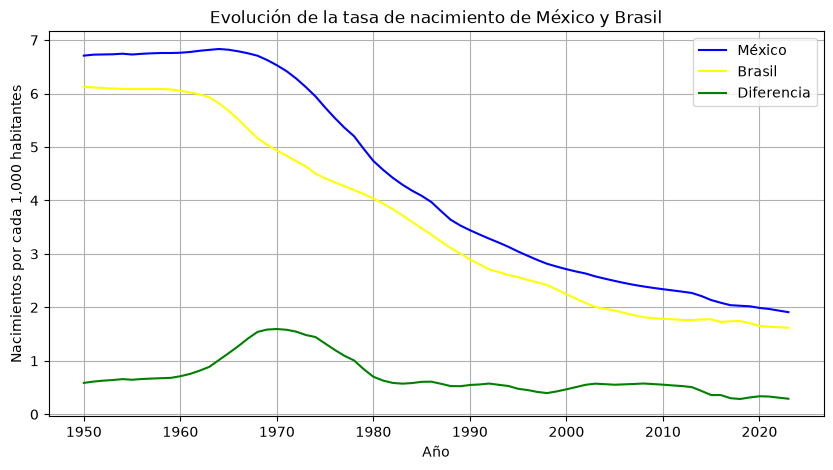

In [109]:
plt.figure(figsize=(10, 5))
plt.plot(
anios_mexico, 
tasa_mexico, 
label="México", 
color="blue"
)
plt.plot(
anios_brasil, 
tasa_brasil,
label="Brasil",
color="yellow"
)
plt.plot(
anios_mexico,
deiferencia_brasil,
label="Diferencia",
color="green"
)

plt.title("Evolución de la tasa de nacimiento de México y Brasil")
plt.xlabel("Año")
plt.ylabel("Nacimientos por cada 1,000 habitantes")
plt.grid(True)
plt.legend()

In [111]:
anios_comunes = np.intersect1d(
    anios_mexico, 
    anios_japon)
anios_comunes

array([1950, 1951, 1952, 1953, 1954, 1955, 1956, 1957, 1958, 1959, 1960,
       1961, 1962, 1963, 1964, 1965, 1966, 1967, 1968, 1969, 1970, 1971,
       1972, 1973, 1974, 1975, 1976, 1977, 1978, 1979, 1980, 1981, 1982,
       1983, 1984, 1985, 1986, 1987, 1988, 1989, 1990, 1991, 1992, 1993,
       1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004,
       2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015,
       2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023])

In [112]:
comparacion_mexico_japon = pd.merge(
    mexico[["year", "fertility_rate_hist"]],
    japon[["year", "fertility_rate_hist"]],
    on="year",
    suffixes=("_mexico", "_japon")
)

In [113]:
comparacion_mexico_japon.head(3)

,year,fertility_rate_hist_mexico,fertility_rate_hist_japon
0,1950,6.709,3.615
1,1951,6.727,3.225
2,1952,6.731,2.947
